In [2]:
import pandas as pd
import geopandas as gpd
import folium

import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

from shapely.wkt import loads

import matplotlib.colors as mcolors
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt

import h3


The objective of this code is to calculate a work-life balance metric, calculating for each cadastral reference the number of people that live there and the number of people that work there.

In [3]:
# Load the data.
    # Sections includes the population data.
    # Buildings_with_section includes the cadastral references and the housing square meters each one has, that will be used as an approximation to distribute the population.

gdf_seccion = gpd.read_file('sections_gipuzkoa_demographic_both.geojson')
gdf_rc = gpd.read_file('buildings_with_section/buildings_with_section.shp')

gdf_rc = gdf_rc.to_crs(epsg=4326)
# gdf_seccion['population'] = gdf_seccion['20-34 años'] + gdf_seccion['35-49 años'] + gdf_seccion['50-64 años']
gdf_seccion['population'] = gdf_seccion['0-19 años'] + gdf_seccion['20-34 años'] + gdf_seccion['35-49 años'] + gdf_seccion['50-64 años'] + gdf_seccion['65-84 años'] + gdf_seccion['85+ años']

# Make the geometry column the centroid one
gdf_rc['centroid_w'] = gdf_rc['centroid_w'].apply(loads)
gdf_rc.set_geometry('centroid_w', inplace=True)

c:\Users\iazcarateu\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: buildings_with_section/buildings_with_section.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [4]:
# To each cadastral reference, I assign a number of population based on the population of the section to which it belongs and the square meters of housing it has

buildings_gdf = gpd.GeoDataFrame(gdf_rc, geometry='centroid_w', crs="EPSG:4326")

buildings_gdf['assigned_population'] = 0

for idx, row in gdf_seccion.iterrows():
    buildings_in_area = buildings_gdf[buildings_gdf.geometry.within(row['geometry'])]
    
    total_area = buildings_in_area['Housing'].sum()
    
    if total_area > 0:
        for b_idx, b_row in buildings_in_area.iterrows():
            proportion = b_row['Housing'] / total_area
            buildings_gdf.at[b_idx, 'assigned_population'] += proportion * row['population']
            buildings_gdf.at[b_idx, 'CUSEC'] = row['CUSEC']

buildings_gdf

C:\Users\iazcarateu\AppData\Local\Temp\ipykernel_19668\2853014730.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.5849037690457097' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  buildings_gdf.at[b_idx, 'assigned_population'] += proportion * row['population']


,Referencia,Housing,centroid_w,geometry,assigned_population,CUSEC
0,7366011,97,POINT (-2.10004 43.04682),"POLYGON ((-2.10014 43.04673, -2.10014 43.04681...",1.584904,2000101001
1,7366002,198,POINT (-2.10425 43.04356),"POLYGON ((-2.10426 43.04363, -2.10416 43.04353...",3.235164,2000101001
2,7366019,153,POINT (-2.09978 43.04682),"POLYGON ((-2.09971 43.04688, -2.09971 43.04677...",2.499900,2000101001
3,7266055,0,POINT (-2.10595 43.04731),"POLYGON ((-2.10568 43.0471, -2.10571 43.04711,...",0.000000,2000101001
4,7266054,0,POINT (-2.10627 43.04764),"POLYGON ((-2.10628 43.04742, -2.10639 43.04737...",0.000000,2000101001
...,...,...,...,...,...,...
58704,7974022,0,POINT (-2.02368 43.11572),"POLYGON ((-2.02388 43.11561, -2.02388 43.11561...",0.000000,2090701001
58705,7974024,0,POINT (-2.02291 43.11737),"POLYGON ((-2.02269 43.11702, -2.02269 43.11702...",0.000000,2090701001
58706,7974041,0,POINT (-2.02368 43.11603),"POLYGON ((-2.02355 43.11594, -2.02365 43.11597...",0.000000,2090701001
58707,7874006,97,POINT (-2.03857 43.11802),"POLYGON ((-2.03857 43.118, -2.03854 43.11802, ...",1.319094,2090701001


In [5]:
buildings_gdf = buildings_gdf.set_geometry('geometry')

# Merge it with job opportunities

In [6]:
est = pd.read_excel('../2_assign_latlong_to_establishments/df_establishments_latlong.xlsx')

est = est[['IDENTIFICADOR', 'CNAE', 'lat', 'long', 'max_num_workers', 'num_workers']]

filas_con_nan = est.isna().sum(axis=1) > 0
num_filas_con_nan = filas_con_nan.sum()
print(f"Cantidad de filas con NaN: {len(est)}")
print(f"Cantidad de filas con NaN: {num_filas_con_nan}")

print(f"Total number of workers: {est['num_workers'].sum()}")

est = est.dropna()
est.head()

Cantidad de filas con NaN: 56038
Cantidad de filas con NaN: 312
Total number of workers: 315408


,IDENTIFICADOR,CNAE,lat,long,max_num_workers,num_workers
0,L0453049,150,43.048444,-2.105448,2,1
1,L0027051,8411,43.048444,-2.105448,9,6
2,L0305841,4941,43.048444,-2.105448,2,2
3,L0304237,145,43.048444,-2.105448,2,2
4,L0528240,7430,43.048444,-2.105448,2,1


In [7]:
# We assign a Cadastral Reference to each establishment based on the building it is located in. We will do a spatial join between the establishments and the buildings, and we will keep the reference of the building in which each establishment is located.

# 1. Convert est (lat/long) → GeoDataFrame
est_gdf = gpd.GeoDataFrame(
    est,
    geometry=gpd.points_from_xy(est['long'], est['lat']),
    crs=buildings_gdf.crs  # assume same CRS (adjust if needed)
)

# 2. Keep only needed columns from buildings
buildings_subset = buildings_gdf[['Referencia', 'geometry']]

# 3. Spatial join (point inside polygon)
result = gpd.sjoin(est_gdf, buildings_subset, how='left', predicate='within')

# 4. If you want it back as a normal DataFrame
result = result.drop(columns='geometry')

num_nan = result['Referencia'].isna().sum()
print(f"Número de establishments que no entran dentro de ninguna RC: {num_nan}")

result

Número de establishments que no entran dentro de ninguna RC: 10927


,IDENTIFICADOR,CNAE,lat,long,max_num_workers,num_workers,index_right,Referencia
0,L0453049,150,43.048444,-2.105448,2,1,NaN,NaN
1,L0027051,8411,43.048444,-2.105448,9,6,NaN,NaN
2,L0305841,4941,43.048444,-2.105448,2,2,NaN,NaN
3,L0304237,145,43.048444,-2.105448,2,2,NaN,NaN
4,L0528240,7430,43.048444,-2.105448,2,1,NaN,NaN
...,...,...,...,...,...,...,...,...
56017,L0021024,8621,43.315413,-1.919039,19,17,46613.0,8796122.0
56019,L0100364,4764,43.279812,-2.013671,99,84,41862.0,8092003.0
56020,L0434604,4711,43.280824,-2.017140,99,56,47053.0,7992031.0
56032,L0026754,5610,43.307744,-2.043110,49,48,46663.0,7795037.0


In [8]:
# Many establishments do not fall within any building, so they do not have a cadastral reference. We will assign them the nearest building's reference.

import numpy as np
from scipy.spatial import cKDTree
import geopandas as gpd

# --- Step 1: ensure est_gdf has geometry and same CRS ---
est_gdf = gpd.GeoDataFrame(
    est,
    geometry=gpd.points_from_xy(est['long'], est['lat']),
    crs=buildings_gdf.crs
)

# --- Step 2: assign Referencia for points inside buildings ---
buildings_subset = buildings_gdf[['Referencia', 'geometry']]
inside_join = gpd.sjoin(est_gdf, buildings_subset, how='left', predicate='within')

# Keep the geometry column for nearest assignment
inside_join = inside_join.set_geometry('geometry')

# --- Step 3: assign nearest building for points without Referencia ---
# Identify points with missing Referencia
missing = inside_join['Referencia'].isna()
if missing.any():
    # Compute building centroids
    building_centroids = buildings_gdf.geometry.centroid
    building_coords = np.array([[pt.x, pt.y] for pt in building_centroids])
    tree = cKDTree(building_coords)

    # Coordinates of missing points
    missing_coords = np.array([[pt.x, pt.y] for pt in inside_join.loc[missing, 'geometry']])

    # Query nearest building for each missing point
    _, nearest_idx = tree.query(missing_coords)

    # Assign the nearest building's Referencia
    inside_join.loc[missing, 'Referencia'] = buildings_gdf.iloc[nearest_idx]['Referencia'].values

# --- Step 4: drop geometry if you want a regular DataFrame ---
result = inside_join.drop(columns='geometry')

# result now has Referencia for all points

C:\Users\iazcarateu\AppData\Local\Temp\ipykernel_19668\3823074542.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  building_centroids = buildings_gdf.geometry.centroid


In [9]:
# Now, to each cadastral reference, we will assign the number of workers that are located in that reference. We will do a groupby on the Referencia column and sum the num_workers for each reference.

workers_per_reference = result.groupby('Referencia')['num_workers'].sum().reset_index()
workers_per_reference.rename(columns={'num_workers': 'total_workers'}, inplace=True)
workers_per_reference

# Now, to buildings_gdf, we will assign the total_workers based on the Referencia. We will do a merge between buildings_gdf and workers_per_reference on the Referencia column.
buildings_gdf = buildings_gdf.merge(workers_per_reference, on='Referencia', how='left')
buildings_gdf['total_workers'] = buildings_gdf['total_workers'].fillna(0)  # fill NaN with 0 for buildings with no workers
buildings_gdf

buildings_gdf.to_csv('rc_pop_workers.csv')

In [10]:
print(f"Total population assigned to RC: {buildings_gdf['assigned_population'].sum()}")
print(f"Total workers assigned to RCs: {buildings_gdf['total_workers'].sum()}")

Total population assigned to RC: 726712.0
Total workers assigned to RCs: 314602.0


# Start creating maps

In [11]:
buildings_plot = buildings_gdf[['geometry', 'assigned_population', 'total_workers']]

# NaN si es 0/0, si es X/0, cambiar por X/1.

buildings_plot['assigned_population'] = buildings_plot['assigned_population'].astype(float)
buildings_plot['total_workers'] = buildings_plot['total_workers'].astype(float)

def safe_divide(population, workers):
    if workers == 0:
        return np.nan if population == 0 else population / 1
    return population / workers

buildings_plot['num'] = buildings_plot.apply(lambda row: safe_divide(row['assigned_population'], row['total_workers']), axis=1)

buildings_plot = buildings_plot[['geometry', 'num']]
buildings_plot

c:\Users\iazcarateu\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\iazcarateu\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\iazcarateu\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A

,geometry,num
0,"POLYGON ((-2.10014 43.04673, -2.10014 43.04681...",1.584904
1,"POLYGON ((-2.10426 43.04363, -2.10416 43.04353...",3.235164
2,"POLYGON ((-2.09971 43.04688, -2.09971 43.04677...",2.499900
3,"POLYGON ((-2.10568 43.0471, -2.10571 43.04711,...",NaN
4,"POLYGON ((-2.10628 43.04742, -2.10639 43.04737...",NaN
...,...,...
58704,"POLYGON ((-2.02388 43.11561, -2.02388 43.11561...",0.000000
58705,"POLYGON ((-2.02269 43.11702, -2.02269 43.11702...",NaN
58706,"POLYGON ((-2.02355 43.11594, -2.02365 43.11597...",NaN
58707,"POLYGON ((-2.03857 43.118, -2.03854 43.11802, ...",1.319094


In [13]:
df = buildings_plot.copy()

min_bin = np.floor(df['num'].min() / 10) * 10  # Asegurar que el mínimo sea múltiplo de 10
max_bin = np.ceil(df['num'].max() / 10) * 10    # Asegurar que el máximo sea múltiplo de 10
bins = np.arange(min_bin, max_bin + 10, 10) 

# Categorize values into bins
df['bin_range'] = pd.cut(df['num'], bins=bins, right=False)

# Count occurrences in each bin
bin_counts = df['bin_range'].value_counts().sort_index()

# Convert to DataFrame for display
table_df = pd.DataFrame({'Range': bin_counts.index.astype(str), 'Count': bin_counts.values})

# Display the table
table_df.head(10)

,Range,Count
0,"[0.0, 10.0)",32725
1,"[10.0, 20.0)",6154
2,"[20.0, 30.0)",2164
3,"[30.0, 40.0)",972
4,"[40.0, 50.0)",529
5,"[50.0, 60.0)",294
6,"[60.0, 70.0)",188
7,"[70.0, 80.0)",139
8,"[80.0, 90.0)",67
9,"[90.0, 100.0)",43


In [14]:
df = buildings_plot.copy()
vmin, vmax = 0, 20
df['norm_num'] = (df['num'] - vmin) / (vmax - vmin)

# Obtener colores de la escala Viridis
colormap = cm.get_cmap('viridis')
df['color'] = df['norm_num'].apply(lambda x: mcolors.to_hex(colormap(x)))

# Crear un mapa centrado en el área de los datos
m = folium.Map(location=[df.geometry.centroid.y.mean(), df.geometry.centroid.x.mean()], zoom_start=10)

for _, row in df.iterrows():
    # Verificar si 'num' es NaN, y si lo es, saltar esa fila
    if pd.isna(row['num']):
        continue
    
    folium.GeoJson(
        row['geometry'],
        style_function=lambda feature, color=row['color']: {
            'fillColor': color,
            'color': color,
            'weight': 2,
            'fillOpacity': 0.6
        }
    ).add_to(m)

m.save('colors.html')

C:\Users\iazcarateu\AppData\Local\Temp\ipykernel_19668\2242069458.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')
C:\Users\iazcarateu\AppData\Local\Temp\ipykernel_19668\2242069458.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  m = folium.Map(location=[df.geometry.centroid.y.mean(), df.geometry.centroid.x.mean()], zoom_start=10)


In [16]:
# buildings_gdf = gpd.GeoDataFrame(buildings_gdf, geometry='geometry')
b_to_shp = buildings_gdf[['Referencia', 'Housing', 'geometry', 'assigned_population', 'total_workers', 'CUSEC']]
b_to_shp.to_file("rc_pop_workers/rc_pop_workers.shp")
buildings_gdf

C:\Users\iazcarateu\AppData\Local\Temp\ipykernel_19668\3160818781.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  b_to_shp.to_file("rc_pop_workers/rc_pop_workers.shp")
c:\Users\iazcarateu\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'assigned_population' to 'assigned_p'
  ogr_write(
c:\Users\iazcarateu\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'total_workers' to 'total_work'
  ogr_write(


,Referencia,Housing,centroid_w,geometry,assigned_population,CUSEC,total_workers
0,7366011,97,POINT (-2.10004 43.04682),"POLYGON ((-2.10014 43.04673, -2.10014 43.04681...",1.584904,2000101001,0.0
1,7366002,198,POINT (-2.10425 43.04356),"POLYGON ((-2.10426 43.04363, -2.10416 43.04353...",3.235164,2000101001,0.0
2,7366019,153,POINT (-2.09978 43.04682),"POLYGON ((-2.09971 43.04688, -2.09971 43.04677...",2.499900,2000101001,0.0
3,7266055,0,POINT (-2.10595 43.04731),"POLYGON ((-2.10568 43.0471, -2.10571 43.04711,...",0.000000,2000101001,0.0
4,7266054,0,POINT (-2.10627 43.04764),"POLYGON ((-2.10628 43.04742, -2.10639 43.04737...",0.000000,2000101001,0.0
...,...,...,...,...,...,...,...
58704,7974022,0,POINT (-2.02368 43.11572),"POLYGON ((-2.02388 43.11561, -2.02388 43.11561...",0.000000,2090701001,27.0
58705,7974024,0,POINT (-2.02291 43.11737),"POLYGON ((-2.02269 43.11702, -2.02269 43.11702...",0.000000,2090701001,0.0
58706,7974041,0,POINT (-2.02368 43.11603),"POLYGON ((-2.02355 43.11594, -2.02365 43.11597...",0.000000,2090701001,0.0
58707,7874006,97,POINT (-2.03857 43.11802),"POLYGON ((-2.03857 43.118, -2.03854 43.11802, ...",1.319094,2090701001,0.0


# Same analysis, but instead of doing it with cadastral references (very granular spatially), by sections, which are 548 in Gipuzkoa.

In [17]:
gdf_secciones = gpd.read_file('sections_gipuzkoa_demographic_both.geojson')
gdf_secciones['population'] = gdf_secciones['0-19 años'] + gdf_secciones['20-34 años'] + gdf_secciones['35-49 años'] + gdf_secciones['50-64 años'] + gdf_secciones['65-84 años'] + gdf_secciones['85+ años']

gdf_est = gpd.read_file("../2_assign_latlong_to_establishments/SHP/establecimientos.shp")
gdf_est

,IDENTIFICA,CNAE,lat,long,max_num_wo,num_worker,geometry
0,L0453049,150,43.048444,-2.105448,2,1,POINT (-2.10545 43.04844)
1,L0027051,8411,43.048444,-2.105448,9,6,POINT (-2.10545 43.04844)
2,L0305841,4941,43.048444,-2.105448,2,2,POINT (-2.10545 43.04844)
3,L0304237,145,43.048444,-2.105448,2,2,POINT (-2.10545 43.04844)
4,L0528240,7430,43.048444,-2.105448,2,1,POINT (-2.10545 43.04844)
...,...,...,...,...,...,...,...
55721,L0021024,8621,43.315413,-1.919039,19,17,POINT (-1.91904 43.31541)
55722,L0100364,4764,43.279812,-2.013671,99,84,POINT (-2.01367 43.27981)
55723,L0434604,4711,43.280824,-2.017140,99,56,POINT (-2.01714 43.28082)
55724,L0026754,5610,43.307744,-2.043110,49,48,POINT (-2.04311 43.30774)


In [18]:
gdf_est['within_section'] = gdf_est.apply(lambda row: gdf_secciones.contains(row.geometry).any(), axis=1)

# 2. Filtramos los puntos que están dentro de las secciones
gdf_est_within = gdf_est[gdf_est['within_section']]

# 3. Ahora vamos a agrupar los puntos dentro de cada polígono y sumar la columna 'num_workers'
workers_per_section = gdf_est_within.groupby(gdf_est_within.geometry.apply(lambda x: gdf_secciones[gdf_secciones.contains(x)].index[0]))['num_worker'].sum()

# 4. Añadimos la nueva columna 'workers' a gdf_secciones, con la suma de 'num_workers' para cada sección
gdf_secciones['workers'] = gdf_secciones.index.map(workers_per_section).fillna(0)

print(gdf_secciones['workers'].sum())
gdf_secciones

314553.0


,CUSEC,CUMUN,Seccion,Distrito,CUDIS,Municipio,Total,0-19 años,20-34 años,35-49 años,50-64 años,65-84 años,85+ años,geometry,population,workers
0,2000101001,20001,001,01,2000101,Abaltzisketa,326,62,49,66,93,49,7,"MULTIPOLYGON (((-2.09892 43.06533, -2.0989 43....",326,126.0
1,2000201001,20002,001,01,2000201,Aduna,505,129,70,127,104,58,17,"MULTIPOLYGON (((-2.03912 43.2023, -2.03915 43....",505,1442.0
2,2000301001,20003,001,01,2000301,Aizarnazabal,771,189,82,214,145,127,14,"MULTIPOLYGON (((-2.20725 43.27294, -2.20714 43...",771,647.0
3,2000401001,20004,001,01,2000401,Albiztur,325,86,36,69,70,55,9,"MULTIPOLYGON (((-2.11304 43.1257, -2.11322 43....",325,157.0
4,2000501001,20005,001,01,2000501,Alegia,1768,364,268,356,416,299,65,"MULTIPOLYGON (((-2.09007 43.1124, -2.08947 43....",1768,555.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,2090301003,20903,003,01,2090301,Astigarraga,2499,496,371,529,617,434,52,"MULTIPOLYGON (((-1.94764 43.28497, -1.9469 43....",2499,2332.0
544,2007902003,20079,003,02,2007902,Zarautz,2117,425,341,485,435,365,66,"MULTIPOLYGON (((-2.17167 43.28256, -2.16995 43...",2117,775.0
545,2007902012,20079,012,02,2007902,Zarautz,5,0,0,2,2,1,0,"MULTIPOLYGON (((-2.169 43.28394, -2.16914 43.2...",5,2.0
546,2006907017,20069,017,07,2006907,Donostia/San Sebastián,1660,305,262,405,353,311,24,"MULTIPOLYGON (((-1.93481 43.31673, -1.93573 43...",1660,313.0


In [19]:
# NaN si es 0/0, si es X/0, cambiar por X/1.

gdf_secciones['population'] = gdf_secciones['population'].astype(float)
gdf_secciones['workers'] = gdf_secciones['workers'].astype(float)

def safe_divide(population, workers):
    if workers == 0:
        return np.nan if population == 0 else population / 1
    return population / workers

gdf_secciones['num'] = gdf_secciones.apply(lambda row: safe_divide(row['population'], row['workers']), axis=1)

In [20]:
df = gdf_secciones.copy()

min_bin = 0  # Asegurar que el mínimo sea múltiplo de 10
max_bin = np.ceil(df['num'].max() / 1) * 1    # Asegurar que el máximo sea múltiplo de 10
bins = np.arange(min_bin, max_bin + 1, 1) 

# Categorize values into bins
df['bin_range'] = pd.cut(df['num'], bins=bins, right=False)

# Count occurrences in each bin
bin_counts = df['bin_range'].value_counts().sort_index()

# Convert to DataFrame for display
table_df = pd.DataFrame({'Range': bin_counts.index.astype(str), 'Count': bin_counts.values})

# Display the table
table_df.head(10)

,Range,Count
0,"[0.0, 1.0)",55
1,"[1.0, 2.0)",80
2,"[2.0, 3.0)",65
3,"[3.0, 4.0)",81
4,"[4.0, 5.0)",57
5,"[5.0, 6.0)",33
6,"[6.0, 7.0)",29
7,"[7.0, 8.0)",22
8,"[8.0, 9.0)",23
9,"[9.0, 10.0)",17


In [21]:
# Copiar el GeoDataFrame original
df = gdf_secciones.copy()

# Rango de valores para la normalización
vmin, vmax = 0, 8
mid = 1  # El valor medio donde cambiaremos la paleta de colores

# Normalización ajustada: los valores por debajo de 'mid' van a la mitad inferior, los valores por encima a la mitad superior
df['norm_num'] = (df['num'] - vmin) / (vmax - vmin)  # Normalización completa de 0 a 1

# Crear una función que mapee la normalización a la paleta de colores de forma que 1 esté en el medio
def custom_color_mapping(norm_num):
    if norm_num <= 0.5:
        # Mapeo para la mitad inferior (por debajo de 1)
        return norm_num * 2  # La normalización se hace de 0 a 1 en la mitad inferior
    else:
        # Mapeo para la mitad superior (por encima de 1)
        return 1 + (norm_num - 0.5) * 2  # La normalización se hace de 1 a 2 en la mitad superior

# Aplicar la nueva normalización a la variable 'norm_num'
df['norm_num'] = df['norm_num'].apply(custom_color_mapping)

# Obtener colores de la escala Viridis (usamos una escala modificada)
colormap = cm.get_cmap('viridis')

# Convertir 'norm_num' a colores hexadecimales
df['color'] = df['norm_num'].apply(lambda x: mcolors.to_hex(colormap(x)))

# Crear el mapa centrado en el área de los datos
m = folium.Map(location=[df.geometry.centroid.y.mean(), df.geometry.centroid.x.mean()], zoom_start=10)

# Añadir las geometrías al mapa con los colores ajustados
for _, row in df.iterrows():
    # Verificar si 'num' es NaN, y si lo es, saltar esa fila
    if pd.isna(row['num']):
        continue
    
    folium.GeoJson(
        row['geometry'],
        style_function=lambda feature, color=row['color']: {
            'fillColor': color,
            'color': color,
            'weight': 2,
            'fillOpacity': 0.6
        }
    ).add_to(m)

# Guardar el mapa en un archivo HTML
m.save('colors_secciones.html')

C:\Users\iazcarateu\AppData\Local\Temp\ipykernel_19668\3547685534.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')
C:\Users\iazcarateu\AppData\Local\Temp\ipykernel_19668\3547685534.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  m = folium.Map(location=[df.geometry.centroid.y.mean(), df.geometry.centroid.x.mean()], zoom_start=10)


# Visualizing in H3 hexagons

In [23]:
# Bring both dfs, the one with establishments latlong (num_workers) and the one with RC latlong (population).

# Cargar los archivos gdf_est y gdf_pop
gdf_est = gpd.read_file("../2_assign_latlong_to_establishments/SHP/establecimientos.shp")
gdf_est = gdf_est[['num_worker', 'geometry']]
gdf_pop = gpd.read_file("../3_assign_population_and_workers_to_cadastral_references/rc_pop_workers/rc_pop_workers.shp")
gdf_pop['geometry'] = gdf_pop['geometry'].centroid
gdf_pop = gdf_pop.rename(columns={'assigned_p': 'population'})
gdf_pop = gdf_pop[['population', 'geometry']]

# gdf_pop

C:\Users\iazcarateu\AppData\Local\Temp\ipykernel_19668\3049628218.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_pop['geometry'] = gdf_pop['geometry'].centroid


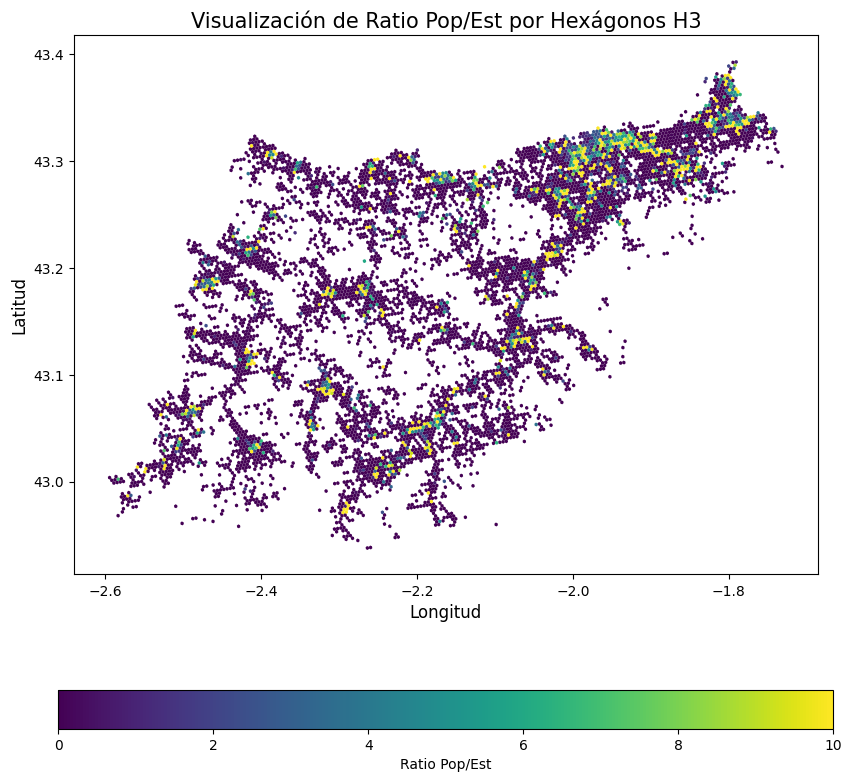

In [24]:
from shapely.geometry import Polygon

# Asegúrate de que ambos GeoDataFrames estén en el mismo sistema de referencia de coordenadas (CRS)
gdf_est = gdf_est.to_crs(epsg=4326)
gdf_pop = gdf_pop.to_crs(epsg=4326)

# Definir la resolución de H3, por ejemplo, resoluciones entre 0 y 15, siendo 0 la más gruesa
res = 9

# Función para asignar celdas H3 a los puntos
def point_to_h3(geom, resolution):
    lat, lon = geom.y, geom.x
    return h3.latlng_to_cell(lat, lon, resolution)

# Asignar celdas H3 a los puntos de gdf_est y gdf_pop
gdf_est['h3_index'] = gdf_est.geometry.apply(lambda x: point_to_h3(x, res))
gdf_pop['h3_index'] = gdf_pop.geometry.apply(lambda x: point_to_h3(x, res))

# Sumar los valores en cada celda H3 para gdf_est y gdf_pop
gdf_est_sum = gdf_est.groupby('h3_index')['num_worker'].sum()
gdf_pop_sum = gdf_pop.groupby('h3_index')['population'].sum()

# Calcular el ratio para cada celda H3
h3_index_all = set(gdf_est_sum.index).union(gdf_pop_sum.index)
ratio_dict = {}

for h3_index in h3_index_all:
    est_value = gdf_est_sum.get(h3_index, 0)
    pop_value = gdf_pop_sum.get(h3_index, 0)
    ratio_dict[h3_index] = pop_value / est_value if est_value != 0 else 0

# Crear un GeoDataFrame para la visualización
h3_hexagons = [
    Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(h3_index)])  # Invertimos lat, lon a lon, lat
    for h3_index in ratio_dict.keys()
]

# Crear la GeoSeries correctamente
geometry = gpd.GeoSeries(h3_hexagons, crs='EPSG:4326')
values = list(ratio_dict.values())

gdf_h3 = gpd.GeoDataFrame({'geometry': geometry, 'ratio': values}, crs='EPSG:4326')

# Plotear la visualización
fig, ax = plt.subplots(figsize=(10, 10))

# Visualizamos los hexágonos, con un color por el valor del ratio
gdf_h3.plot(ax=ax, column='ratio', cmap='viridis', legend=True,
            legend_kwds={'label': "Ratio Pop/Est", 'orientation': "horizontal"}, vmin=0, vmax=10)

# Opcional: Agregar límites de Gipuzkoa si lo tienes
# gdf_gipuzkoa = gpd.read_file('ruta_a_tu_shapefile_gipuzkoa.shp')  # Si tienes el shapefile de Gipuzkoa
# gdf_gipuzkoa.boundary.plot(ax=ax, color='black')

ax.set_title('Visualización de Ratio Pop/Est por Hexágonos H3', fontsize=15)
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)

plt.show()

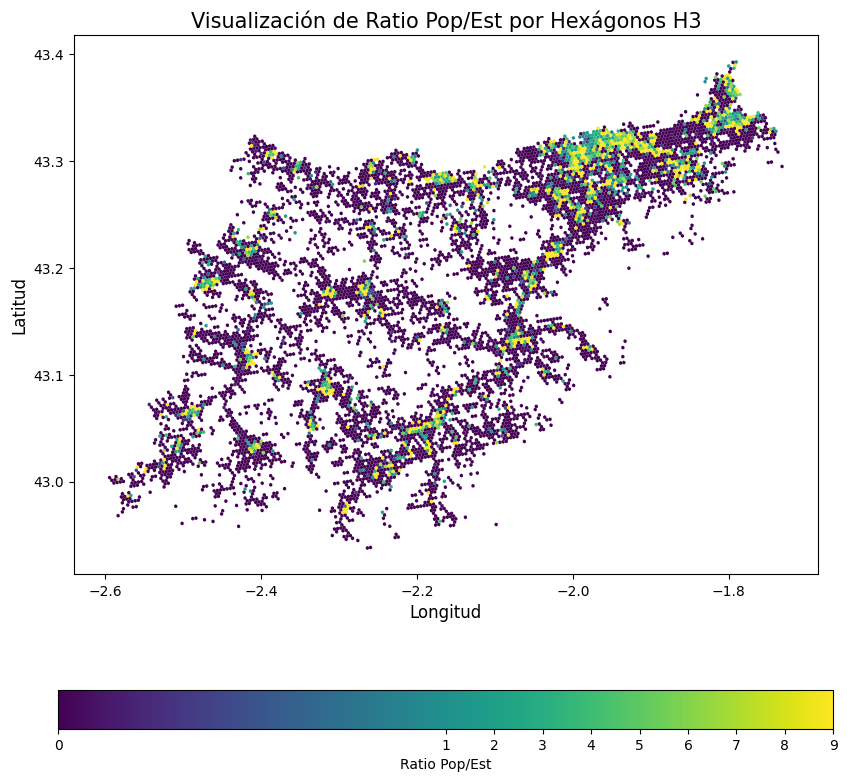

In [25]:
from shapely.geometry import Polygon

# Asegúrate de que ambos GeoDataFrames estén en el mismo sistema de referencia de coordenadas (CRS)
gdf_est = gdf_est.to_crs(epsg=4326)
gdf_pop = gdf_pop.to_crs(epsg=4326)

# Definir la resolución de H3, por ejemplo, resoluciones entre 0 y 15, siendo 0 la más gruesa
res = 9

# Función para asignar celdas H3 a los puntos
def point_to_h3(geom, resolution):
    lat, lon = geom.y, geom.x
    return h3.latlng_to_cell(lat, lon, resolution)

# Asignar celdas H3 a los puntos de gdf_est y gdf_pop
gdf_est['h3_index'] = gdf_est.geometry.apply(lambda x: point_to_h3(x, res))
gdf_pop['h3_index'] = gdf_pop.geometry.apply(lambda x: point_to_h3(x, res))

# Sumar los valores en cada celda H3 para gdf_est y gdf_pop
gdf_est_sum = gdf_est.groupby('h3_index')['num_worker'].sum()
gdf_pop_sum = gdf_pop.groupby('h3_index')['population'].sum()

# Calcular el ratio para cada celda H3
h3_index_all = set(gdf_est_sum.index).union(gdf_pop_sum.index)
ratio_dict = {}

for h3_index in h3_index_all:
    est_value = gdf_est_sum.get(h3_index, 0)
    pop_value = gdf_pop_sum.get(h3_index, 0)
    ratio_dict[h3_index] = pop_value / est_value if est_value != 0 else 0

# Crear un GeoDataFrame para la visualización
h3_hexagons = [
    Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(h3_index)])  # Invertimos lat, lon a lon, lat
    for h3_index in ratio_dict.keys()
]

# Crear la GeoSeries correctamente
geometry = gpd.GeoSeries(h3_hexagons, crs='EPSG:4326')
values = list(ratio_dict.values())

gdf_h3 = gpd.GeoDataFrame({'geometry': geometry, 'ratio': values}, crs='EPSG:4326')

norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1, vmax=9)

# Plotear la visualización
fig, ax = plt.subplots(figsize=(10, 10))

# Visualizamos los hexágonos, con un color por el valor del ratio
gdf_h3.plot(ax=ax, column='ratio', cmap='viridis', norm=norm, legend=True,
            legend_kwds={'label': "Ratio Pop/Est", 'orientation': "horizontal"})

# Opcional: Agregar límites de Gipuzkoa si lo tienes
# gdf_gipuzkoa = gpd.read_file('ruta_a_tu_shapefile_gipuzkoa.shp')  # Si tienes el shapefile de Gipuzkoa
# gdf_gipuzkoa.boundary.plot(ax=ax, color='black')

ax.set_title('Visualización de Ratio Pop/Est por Hexágonos H3', fontsize=15)
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)

plt.show()